## Assignment 3 — Forward Propagation and Backpropagation

## Import Libraries

In [1]:
# 1. Import required libraries
# TensorFlow/Keras is used to build and train the neural network.
# NumPy is used for numerical operations.
# Matplotlib is used for visualization.
# Pandas is used to store and compare experimental results.

import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.21.0
Keras version: 3.13.2


## Dataset
# Load and Prepare the Dataset

The MNIST dataset contains handwritten digits from 0 to 9.

- 60,000 images are available for training.
- 10,000 images are available for testing.
- Each image has a size of 28 × 28 pixels.
- There are 10 output classes representing digits 0 to 9.

The pixel values are normalized from the range 0-255 to the range 0-1.

In [2]:
# 2. Load the MNIST dataset
# The dataset is divided into training and testing sets.

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)
Training labels: (60000,)
Testing labels: (10000,)


## Preprocessing

In [3]:
# 3. Data preprocessing and normalization
# Pixel values range from 0 to 255.
# Dividing by 255 converts the values into the range 0 to 1.
# Normalization helps the neural network learn efficiently.

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Visualize the Images

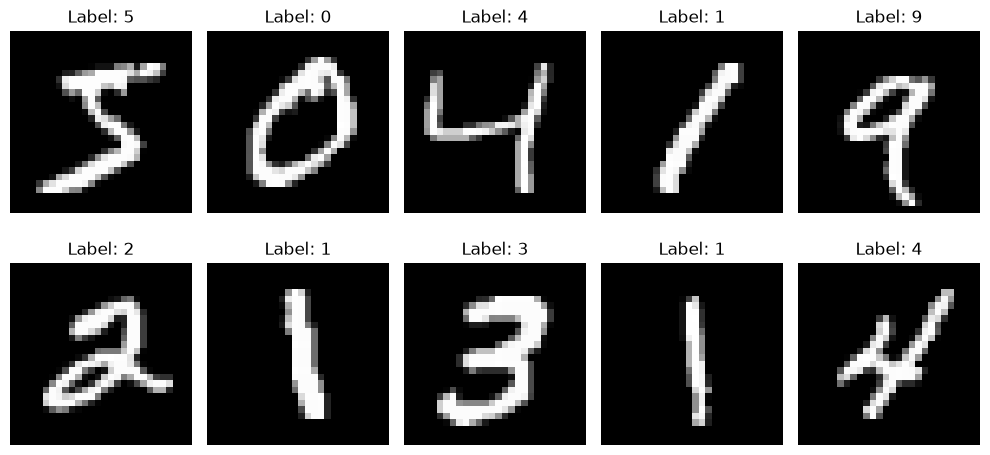

In [4]:
#Before training the model, a few images from the dataset are displayed to understand the input data.  

# 4. Visualize sample images from the MNIST dataset
# The images are displayed along with their corresponding labels.

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Label: " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

## Model Architecture

## Neural Network Architecture

The neural network used in this assignment consists of:

- Input layer: 28 × 28 image
- Flatten layer: converts the image into a 784-element vector
- Hidden layer: 128 neurons with ReLU activation
- Output layer: 10 neurons with Softmax activation

The Softmax output gives the probability of each digit class.

## Create Model

In [5]:
# 5. Create the neural network model
# Flatten converts the 28x28 image into a 784-element vector.
# Dense layer with 128 neurons performs feature learning.
# The output layer contains 10 neurons for digits 0-9.

model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Forward Propagation

Forward propagation is the process of passing input data through the neural network.

The input image passes through the following operations:

1. Flatten the input image.
2. Calculate the weighted sum in the hidden layer.
3. Apply the ReLU activation function.
4. Pass the result to the output layer.
5. Apply Softmax to obtain class probabilities.

The output represents the predicted probabilities for digits 0 to 9.

In [6]:
# 6. Perform forward propagation
# A sample image is passed through the model.
# The model produces probability values for all 10 digit classes.

sample_image = x_train[:1]

output = model(sample_image, training=False)

print("Output probabilities:")
print(output.numpy())

print("\nPredicted class:", np.argmax(output.numpy()))
print("Actual class:", y_train[0])

Output probabilities:
[[0.05730626 0.13324131 0.11884249 0.1978326  0.11154636 0.1011342
  0.04483689 0.10559526 0.05067255 0.07899208]]

Predicted class: 3
Actual class: 5


## Loss Function


## Loss Calculation

The Sparse Categorical Crossentropy loss function is used because the target labels are integer values from 0 to 9.

The loss measures the difference between the actual class and the predicted probability distribution.

In [7]:
# 7. Calculate the loss
# Sparse categorical crossentropy measures the difference
# between the actual label and predicted probabilities.

loss_function = keras.losses.SparseCategoricalCrossentropy()

sample_loss = loss_function(
    y_train[:1],
    output
)

print("Initial loss:", sample_loss.numpy())

Initial loss: 2.291307


## Backpropagation

Backpropagation is used to update the weights of the neural network.

TensorFlow's `GradientTape` records the operations performed during forward propagation. It then calculates the gradients of the loss with respect to the model weights.

The optimizer uses these gradients to update the weights and reduce the loss.

The basic process is:

1. Perform forward propagation.
2. Calculate the loss.
3. Calculate gradients using GradientTape.
4. Update the weights using the optimizer.

## Implement Backpropagation

In [8]:
# 8. Implement backpropagation using GradientTape
# GradientTape calculates the gradients of the loss
# with respect to the trainable model parameters.
# The optimizer then updates the model weights.

optimizer = keras.optimizers.Adam(learning_rate=0.001)

with tf.GradientTape() as tape:
    predictions = model(x_train[:32], training=True)
    loss = loss_function(y_train[:32], predictions)

gradients = tape.gradient(loss, model.trainable_variables)

optimizer.apply_gradients(
    zip(gradients, model.trainable_variables)
)

print("Backpropagation completed successfully.")
print("Loss before weight update:", loss.numpy())

Backpropagation completed successfully.
Loss before weight update: 2.2977214


## Training


The neural network is trained using forward propagation and backpropagation.

During training:

- Forward propagation generates predictions.
- The loss function calculates the error.
- Backpropagation calculates gradients.
- The optimizer updates the weights.

Different learning rates will be tested to analyze their effect on model performance.

In [9]:
# 9. Create a function for training the model
# This function trains a new neural network using
# the specified learning rate and number of epochs.

def create_model():
    model = keras.Sequential([
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(10, activation="softmax")
    ])
    return model


def train_model(learning_rate, epochs):
    
    model = create_model()
    
    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )
    
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    history = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )
    
    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )
    
    return model, history, test_loss, test_accuracy

print("Training function created successfully.")

Training function created successfully.


## Learning Rate Experiment

## Experiment with Different Learning Rates

Learning rate determines how much the model weights are changed during each update.

Three learning rates are tested:

- 0.0001 — slow learning
- 0.001 — moderate learning
- 0.01 — faster learning

The performance of each model is compared using test accuracy and test loss.

## Different Learning Rates

In [10]:
# 10. Analyze the effect of different learning rates
# Three different learning rates are tested.
# The number of epochs is kept constant at 5.

learning_rates = [0.0001, 0.001, 0.01]

learning_rate_results = []

for lr in learning_rates:
    
    print("\n" + "=" * 50)
    print("Learning Rate:", lr)
    print("=" * 50)
    
    model_lr, history_lr, test_loss, test_accuracy = train_model(
        learning_rate=lr,
        epochs=5
    )
    
    learning_rate_results.append({
        "Learning Rate": lr,
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy
    })

learning_rate_df = pd.DataFrame(learning_rate_results)

print("\nLearning Rate Comparison:")
print(learning_rate_df)


Learning Rate: 0.0001
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7446 - loss: 1.0541 - val_accuracy: 0.9012 - val_loss: 0.4617
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8901 - loss: 0.4389 - val_accuracy: 0.9220 - val_loss: 0.3102
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9075 - loss: 0.3459 - val_accuracy: 0.9303 - val_loss: 0.2612
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9167 - loss: 0.3029 - val_accuracy: 0.9382 - val_loss: 0.2323
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9242 - loss: 0.2746 - val_accuracy: 0.9415 - val_loss: 0.2138

Learning Rate: 0.001
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8972 - loss: 0.3778 - val_accuracy: 0.9532 - val_loss: 0.1734
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9482 - loss: 0.1800 - val_accuracy: 0.9647 - val_loss: 0.1299
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9

## Learning Rate Graph

## Learning Rate Performance Comparison

The test accuracy of models trained with different learning rates is compared using a bar graph.

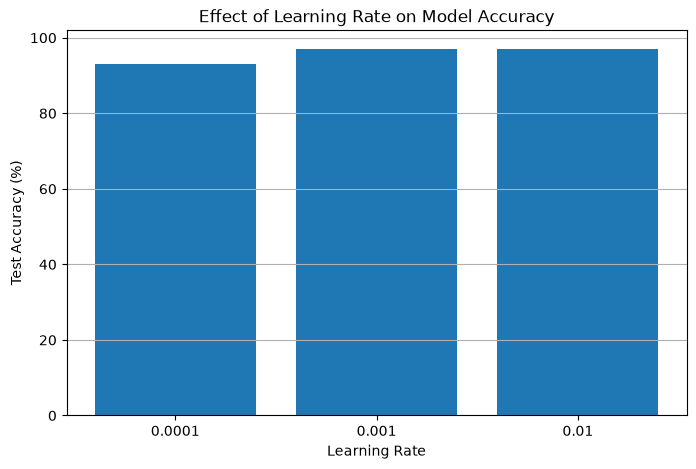

In [11]:
# 11. Visualize the effect of learning rate
# The graph compares test accuracy for different learning rates.

plt.figure(figsize=(8, 5))

plt.bar(
    learning_rate_df["Learning Rate"].astype(str),
    learning_rate_df["Test Accuracy"] * 100
)

plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy (%)")
plt.title("Effect of Learning Rate on Model Accuracy")
plt.grid(axis="y")

plt.show()

## Epoch Experiment

## Experiment with Different Numbers of Epochs

An epoch represents one complete pass through the training dataset.

Three different epoch values are tested:

- 3 epochs
- 5 epochs
- 10 epochs

The learning rate is kept constant at 0.001.

The purpose is to observe how increasing the number of epochs affects model performance.

In [12]:
# 12. Analyze the effect of different numbers of epochs
# The learning rate is kept constant at 0.001.

epoch_values = [3, 5, 10]

epoch_results = []

for epochs in epoch_values:
    
    print("\n" + "=" * 50)
    print("Number of Epochs:", epochs)
    print("=" * 50)
    
    model_epoch, history_epoch, test_loss, test_accuracy = train_model(
        learning_rate=0.001,
        epochs=epochs
    )
    
    epoch_results.append({
        "Epochs": epochs,
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy
    })

epoch_df = pd.DataFrame(epoch_results)

print("\nEpoch Comparison:")
print(epoch_df)


Number of Epochs: 3
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8952 - loss: 0.3764 - val_accuracy: 0.9557 - val_loss: 0.1734
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9494 - loss: 0.1775 - val_accuracy: 0.9642 - val_loss: 0.1222
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9631 - loss: 0.1280 - val_accuracy: 0.9702 - val_loss: 0.1001

Number of Epochs: 5
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8952 - loss: 0.3777 - val_accuracy: 0.9578 - val_loss: 0.1665
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9514 - loss: 0.1711 - val_accuracy: 0.9672 - val_loss: 0.1283
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9636 - loss: 0.1250 - val_accuracy: 0.9710 - val_loss: 0.1068
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9717 - loss: 0.0977 - val_accuracy: 0.9715 - val_loss: 0.0954
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9763

## Epoch Graph

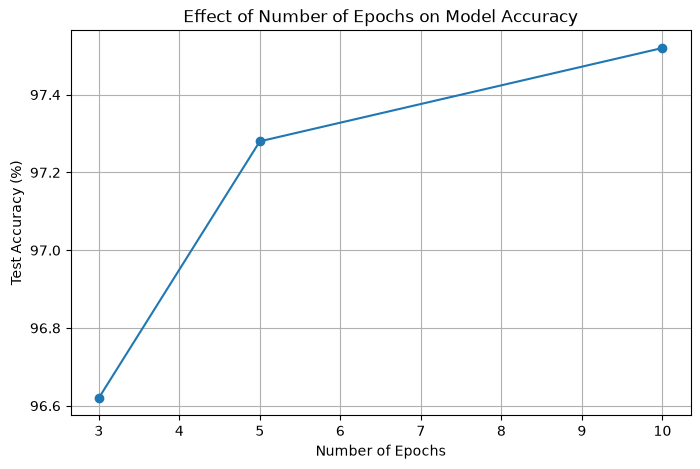

In [13]:
# 13. Visualize the effect of number of epochs
# The graph compares test accuracy for different epoch values.

plt.figure(figsize=(8, 5))

plt.plot(
    epoch_df["Epochs"],
    epoch_df["Test Accuracy"] * 100,
    marker="o"
)

plt.xlabel("Number of Epochs")
plt.ylabel("Test Accuracy (%)")
plt.title("Effect of Number of Epochs on Model Accuracy")
plt.grid()

plt.show()

## Training Graph

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8953 - loss: 0.3773 - val_accuracy: 0.9542 - val_loss: 0.1736
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9516 - loss: 0.1698 - val_accuracy: 0.9662 - val_loss: 0.1202
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9651 - loss: 0.1206 - val_accuracy: 0.9743 - val_loss: 0.0990
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9724 - loss: 0.0939 - val_accuracy: 0.9738 - val_loss: 0.0897
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9777 - loss: 0.0769 - val_accuracy: 0.9768 - val_loss: 0.0831
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9823 - loss: 0.0633 - val_accuracy: 0.9765 - val_loss: 0.0808
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9851 - loss: 0.0537 - val_accuracy: 0.9783 - val_loss: 0.0763
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9872 - loss: 0.0448 - val_accuracy: 0.

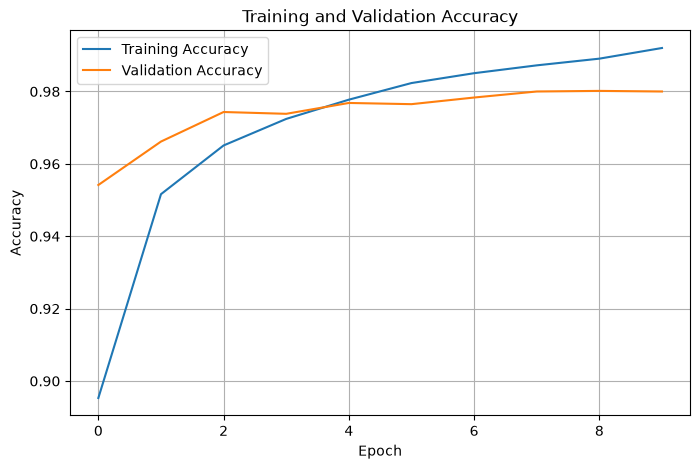

In [14]:
# 14. Train a final model and visualize its training performance
# A learning rate of 0.001 and 10 epochs are used.

final_model, final_history, final_test_loss, final_test_accuracy = train_model(
    learning_rate=0.001,
    epochs=10
)

plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

## Loss Graph

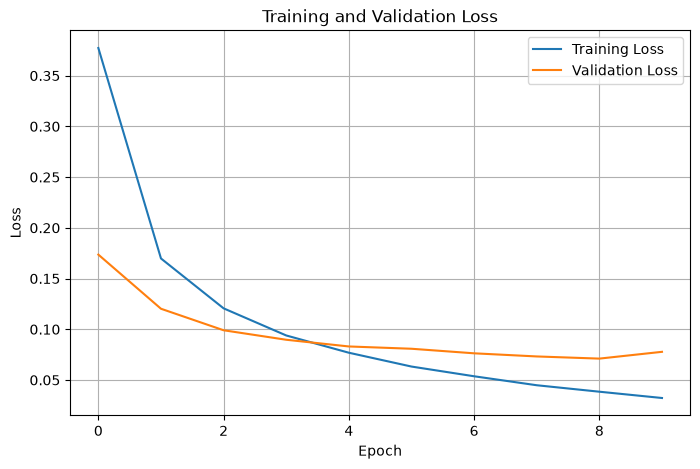

In [15]:
# 15. Plot training and validation loss
# The loss graph shows how the error changes during training.

plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

## Final Accuracy

In [16]:
# 16. Evaluate the final model
# The final model is evaluated using the unseen test dataset.

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print("Test Loss:", final_test_loss)
print("Test Accuracy:", final_test_accuracy)
print("Test Accuracy: {:.2f}%".format(final_test_accuracy * 100))

FINAL MODEL PERFORMANCE
Test Loss: 0.0826677456498146
Test Accuracy: 0.9747999906539917
Test Accuracy: 97.48%


## Prediction

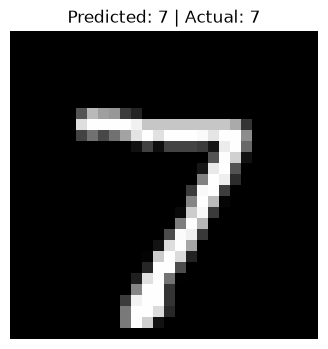

Predicted digit: 7
Actual digit: 7


In [17]:
# 17. Predict a sample test image
# The trained model predicts the digit present in the selected image.

sample_index = 0

prediction = final_model.predict(
    x_test[sample_index:sample_index + 1],
    verbose=0
)

predicted_digit = np.argmax(prediction)

plt.figure(figsize=(4, 4))

plt.imshow(
    x_test[sample_index],
    cmap="gray"
)

plt.title(
    "Predicted: {} | Actual: {}".format(
        predicted_digit,
        y_test[sample_index]
    )
)

plt.axis("off")
plt.show()

print("Predicted digit:", predicted_digit)
print("Actual digit:", y_test[sample_index])